# 📊 **Phase 2: Data Exploration & Analysis**

**Objective**: Explore and analyze Sweden's electricity demand data to understand patterns, trends, and characteristics that will inform our forecasting approach.

**Dataset**: Processed hourly electricity demand data for Sweden from Open Power System Data


---

## 📋 Task 1: Data Quality Assessment

Load processed data and examine basic properties.

In [3]:
# Essential imports for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")

✅ Libraries imported successfully!
📊 Pandas version: 2.3.3
🔢 NumPy version: 2.3.3


In [4]:
# Load the processed data
data_path = Path("../data/processed/sweden_processed_hourly.csv")

print(f"📁 Loading data from: {data_path}")
print(f"✅ File exists: {data_path.exists()}")

# Load data with proper datetime parsing
df = pd.read_csv(data_path, index_col='utc_timestamp', parse_dates=True)

print(f"\n🎯 Data loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📅 Date range: {df.index.min()} to {df.index.max()}")
print(f"⏱️  Total time span: {df.index.max() - df.index.min()}")

# Display first few rows
print(f"\n🔍 First 5 rows:")
df.head()

📁 Loading data from: ..\data\processed\sweden_processed_hourly.csv
✅ File exists: True

🎯 Data loaded successfully!
📊 Shape: (50401, 2)
📅 Date range: 2014-12-31 23:00:00+00:00 to 2020-09-30 23:00:00+00:00
⏱️  Total time span: 2100 days 00:00:00

🔍 First 5 rows:


,SE_load_actual_entsoe_transparency,SE_load_forecast_entsoe_transparency
utc_timestamp,,
2014-12-31 23:00:00+00:00,14485.0,13614.0
2015-01-01 00:00:00+00:00,14485.0,13614.0
2015-01-01 01:00:00+00:00,14485.0,13614.0
2015-01-01 02:00:00+00:00,14298.0,13502.0
2015-01-01 03:00:00+00:00,14249.0,13494.0


In [5]:
# Basic data inspection
print("🔍 Data Types and Basic Info:")
print("=" * 50)
print(df.dtypes)
print(f"\n📊 Dataset Overview:")
print(f"   Columns: {list(df.columns)}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Check for missing values
print(f"\n❓ Missing Values Analysis:")
missing_stats = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

for col in df.columns:
    print(f"   {col}: {missing_stats[col]} missing ({missing_pct[col]:.3f}%)")

print(f"\n✅ Total missing values: {df.isnull().sum().sum()}")

🔍 Data Types and Basic Info:
SE_load_actual_entsoe_transparency      float64
SE_load_forecast_entsoe_transparency    float64
dtype: object

📊 Dataset Overview:
   Columns: ['SE_load_actual_entsoe_transparency', 'SE_load_forecast_entsoe_transparency']
   Memory usage: 1.15 MB

❓ Missing Values Analysis:
   SE_load_actual_entsoe_transparency: 0 missing (0.000%)
   SE_load_forecast_entsoe_transparency: 0 missing (0.000%)

✅ Total missing values: 0


In [6]:
# Statistical summary of the data
print("📈 Statistical Summary:")
print("=" * 50)
print(df.describe())

# More detailed statistics
print(f"\n🎯 Key Statistics for Actual Load:")
actual_col = 'SE_load_actual_entsoe_transparency'
print(f"   Mean: {df[actual_col].mean():.2f} MW")
print(f"   Median: {df[actual_col].median():.2f} MW") 
print(f"   Min: {df[actual_col].min():.2f} MW")
print(f"   Max: {df[actual_col].max():.2f} MW")
print(f"   Standard Deviation: {df[actual_col].std():.2f} MW")
print(f"   Coefficient of Variation: {(df[actual_col].std()/df[actual_col].mean())*100:.2f}%")

📈 Statistical Summary:
       SE_load_actual_entsoe_transparency  \
count                        50401.000000   
mean                         15519.670169   
std                           3348.539704   
min                           5043.000000   
25%                          12909.000000   
50%                          15163.000000   
75%                          17861.000000   
max                          26714.000000   

       SE_load_forecast_entsoe_transparency  
count                          50401.000000  
mean                           15606.485367  
std                             3346.930149  
min                             8416.000000  
25%                            12991.000000  
50%                            15258.000000  
75%                            17964.000000  
max                            26416.000000  

🎯 Key Statistics for Actual Load:
   Mean: 15519.67 MW
   Median: 15163.00 MW
   Min: 5043.00 MW
   Max: 26714.00 MW
   Standard Deviation: 3348.54 MW
   Co

In [7]:
# Check temporal continuity (gaps in time series)
print("⏰ Temporal Continuity Analysis:")
print("=" * 50)

# Expected hourly frequency
expected_freq = pd.Timedelta(hours=1)
time_diffs = df.index.to_series().diff().dropna()

# Find gaps
gaps = time_diffs[time_diffs > expected_freq]
print(f"📅 Expected frequency: Every {expected_freq}")
print(f"🔍 Number of gaps > 1 hour: {len(gaps)}")

if len(gaps) > 0:
    print(f"📊 Gap analysis:")
    print(f"   Largest gap: {gaps.max()}")
    print(f"   Average gap size: {gaps.mean()}")
    print(f"   First few gaps:")
    for i, (timestamp, gap) in enumerate(gaps.head().items()):
        print(f"     {timestamp}: {gap}")
        if i >= 4:  # Show max 5 gaps
            break
else:
    print("✅ No gaps found - perfect hourly continuity!")

# Check index properties
print(f"\n📋 Index Properties:")
print(f"   Index type: {type(df.index).__name__}")
print(f"   Timezone: {df.index.tz}")
print(f"   Is monotonic: {df.index.is_monotonic_increasing}")

⏰ Temporal Continuity Analysis:
📅 Expected frequency: Every 0 days 01:00:00
🔍 Number of gaps > 1 hour: 0
✅ No gaps found - perfect hourly continuity!

📋 Index Properties:
   Index type: DatetimeIndex
   Timezone: UTC
   Is monotonic: True


---

## 📈 Task 2: Temporal Pattern Visualization

Visualize electricity load patterns to understand trends, seasonality, and cyclical behavior.

📊 Overview: 50,401 hourly observations from 2014-12-31 to 2020-09-30


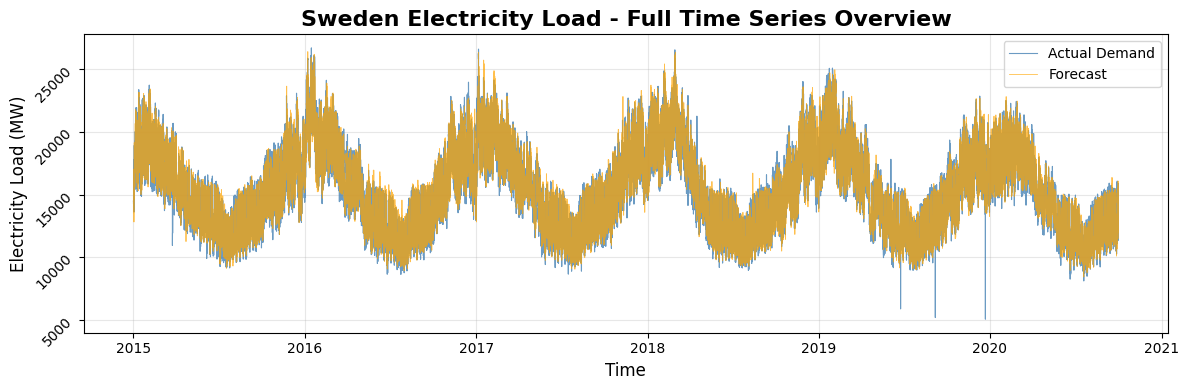

In [8]:
# Full time series overview
fig, ax = plt.subplots(figsize=(12, 4))

# Plot actual demand
ax.plot(df.index, df['SE_load_actual_entsoe_transparency'], 
        color='steelblue', linewidth=0.8, alpha=0.8, label='Actual Demand')

# Add forecast for comparison
ax.plot(df.index, df['SE_load_forecast_entsoe_transparency'], 
        color='orange', linewidth=0.6, alpha=0.7, label='Forecast')

ax.set_title('Sweden Electricity Load - Full Time Series Overview', fontsize=16, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Electricity Load (MW)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Format y-axis to use less space
ax.tick_params(axis='y', rotation=45)

print(f"📊 Overview: {len(df):,} hourly observations from {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
plt.tight_layout()
plt.show()


📅 Monthly aggregated insights:
   Highest load month: Jan (19590 MW)
   Lowest load month: Jul (11759 MW)
   Monthly load variation range: 7831 MW (peak-to-valley)
   Monthly load variation: ±25.1% around annual average


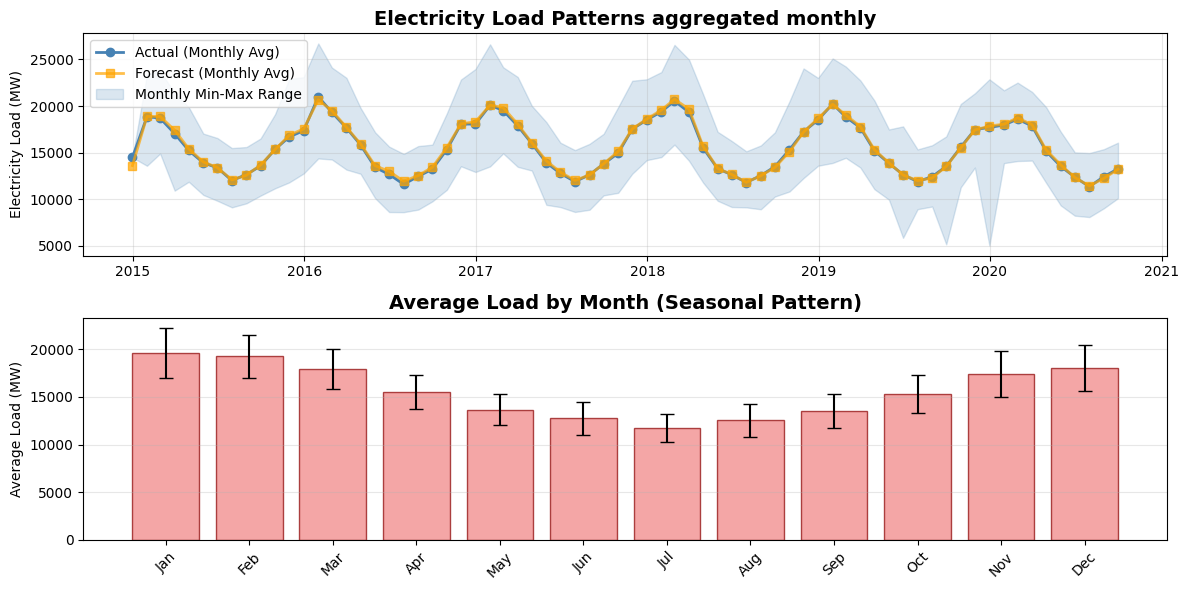

In [32]:
# Monthly aggregated patterns
df_monthly = df.resample('M').agg({
    'SE_load_actual_entsoe_transparency': ['mean', 'min', 'max'],
    'SE_load_forecast_entsoe_transparency': 'mean'
}).round(2)

# Flatten column names
df_monthly.columns = ['Actual_Mean', 'Actual_Min', 'Actual_Max', 'Forecast_Mean']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Monthly averages
ax1.plot(df_monthly.index, df_monthly['Actual_Mean'], 
         marker='o', linewidth=2, color='steelblue', label='Actual (Monthly Avg)')
ax1.plot(df_monthly.index, df_monthly['Forecast_Mean'], 
         marker='s', linewidth=2, color='orange', alpha=0.7, label='Forecast (Monthly Avg)')
ax1.fill_between(df_monthly.index, df_monthly['Actual_Min'], df_monthly['Actual_Max'], 
                 alpha=0.2, color='steelblue', label='Monthly Min-Max Range')

ax1.set_title('Electricity Load Patterns aggregated monthly', fontsize=14, fontweight='bold')
ax1.set_ylabel('Electricity Load (MW)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Seasonal pattern (average by month of year)
df['month'] = df.index.month # 01-12
monthly_seasonal = df.groupby('month')['SE_load_actual_entsoe_transparency'].agg(['mean', 'std'])
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


ax2.bar(months, monthly_seasonal['mean'], yerr=monthly_seasonal['std'], 
        capsize=5, color='lightcoral', alpha=0.7, edgecolor='darkred')
ax2.set_title('Average Load by Month (Seasonal Pattern)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Load (MW)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

print(f"📅 Monthly aggregated insights:")
print(f"   Highest load month: {months[monthly_seasonal['mean'].idxmax()-1]} ({monthly_seasonal['mean'].max():.0f} MW)")
print(f"   Lowest load month: {months[monthly_seasonal['mean'].idxmin()-1]} ({monthly_seasonal['mean'].min():.0f} MW)")
print(f"   Monthly load variation range: {((monthly_seasonal['mean'].max() - monthly_seasonal['mean'].min())):.0f} MW (peak-to-valley)")
print(f"   Monthly load variation: ±{((monthly_seasonal['mean'].max() - monthly_seasonal['mean'].min()) / 2 / monthly_seasonal['mean'].mean() * 100):.1f}% around annual average")


plt.tight_layout()
plt.show()


📊 Weekly insights:
   Highest load day: Wednesday (16085 MW)
   Lowest load day: Sunday (14382 MW)
   Day load variation range: 1703 MW (peak-to-valley)
   Day load variation: ±5.5% around weekly average
📊 Daily insights:
   Peak hour: 9:00 (16906 MW)
   Low hour: 1:00 (13202 MW)
   Hourly load variation range: 3703 MW (peak-to-valley)
   Hourly load variation: ±11.9% around daily average


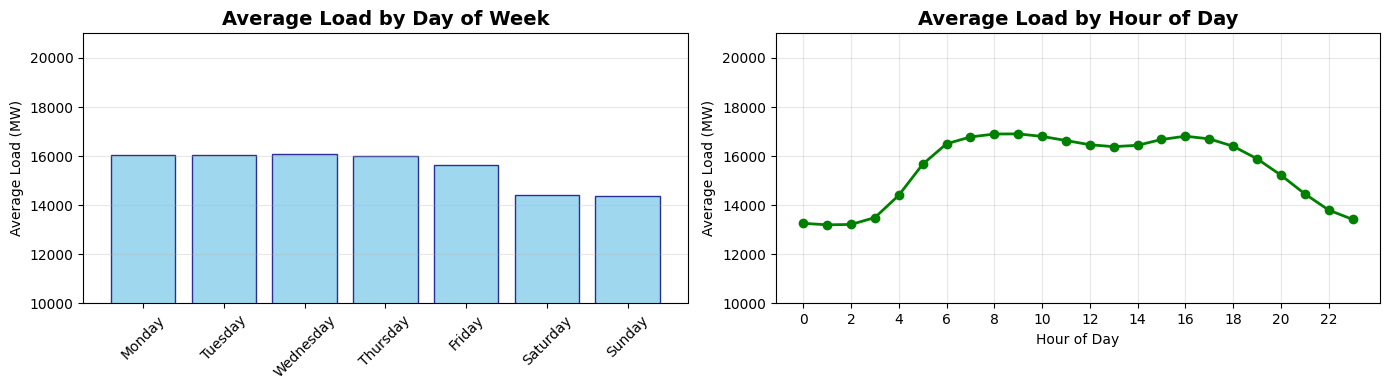

In [40]:
# Weekly patterns
# Add temporal features for analysis (modifying original df for convenience in EDA)
df['weekday'] = df.index.weekday  # 0=Monday, 6=Sunday
df['hour'] = df.index.hour # 0-23

# Average demand by day of week
weekly_pattern = df.groupby('weekday')['SE_load_actual_entsoe_transparency'].mean()
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

y_min=10000
y_max=21000

# Daily pattern
ax1.bar(weekdays, weekly_pattern.values, color='skyblue', alpha=0.8, edgecolor='navy')
ax1.set_title('Average Load by Day of Week', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Load (MW)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')
# Set consistent y-axis limits
ax1.set_ylim(y_min, y_max)

# Hourly pattern
hourly_pattern = df.groupby('hour')['SE_load_actual_entsoe_transparency'].mean()
ax2.plot(hourly_pattern.index, hourly_pattern.values, marker='o', linewidth=2, color='green')
ax2.set_title('Average Load by Hour of Day', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Average Load (MW)')
ax2.set_xticks(range(0, 24, 2))
ax2.grid(True, alpha=0.3)
ax2.set_ylim(y_min, y_max)

print(f"📊 Weekly insights:")
print(f"   Highest load day: {weekdays[weekly_pattern.idxmax()]} ({weekly_pattern.max():.0f} MW)")
print(f"   Lowest load day: {weekdays[weekly_pattern.idxmin()]} ({weekly_pattern.min():.0f} MW)")
print(f"   Day load variation range: {((weekly_pattern.max() - weekly_pattern.min())):.0f} MW (peak-to-valley)")
print(f"   Day load variation: ±{((weekly_pattern.max() - weekly_pattern.min()) / 2 / weekly_pattern.mean() * 100):.1f}% around weekly average")
print(f"📊 Daily insights:")
print(f"   Peak hour: {hourly_pattern.idxmax()}:00 ({hourly_pattern.max():.0f} MW)")
print(f"   Low hour: {hourly_pattern.idxmin()}:00 ({hourly_pattern.min():.0f} MW)")
print(f"   Hourly load variation range: {((hourly_pattern.max() - hourly_pattern.min())):.0f} MW (peak-to-valley)")
print(f"   Hourly load variation: ±{((hourly_pattern.max() - hourly_pattern.min()) / 2 / hourly_pattern.mean() * 100):.1f}% around daily average")

plt.tight_layout()
plt.show()


---

## 🌡️ Task 3: Seasonality & Trend Analysis

Decompose the time series to understand its underlying components: trend, seasonality, and residuals.

### 🔍 Understanding Time Series Decomposition

**Time series decomposition** is a statistical technique that breaks down a time series into its fundamental components to better understand the underlying patterns.

**What does `seasonal_decompose` do?**
- It separates your electricity demand data into distinct, interpretable components
- Uses either **additive** or **multiplicative** models:
  - **Additive**: `Observed = Trend + Seasonal + Residual` (what we're using)
  - **Multiplicative**: `Observed = Trend × Seasonal × Residual`

**The Four Components:**

1. **📈 Original/Observed**: Your raw electricity demand data (what actually happened)

2. **📊 Trend Component**: 
   - The long-term direction of electricity demand over time
   - Shows whether demand is generally increasing, decreasing, or stable
   - Removes short-term fluctuations to reveal the underlying trajectory
   - *Example*: Sweden's electricity demand might show an upward trend due to economic growth

3. **🌡️ Seasonal Component**: 
   - Regular, predictable patterns that repeat over fixed periods (yearly cycles)
   - Captures recurring variations like winter heating vs summer cooling
   - Always has the same pattern each year (high in winter, low in summer)
   - *Example*: Higher demand in December-February, lower in June-August

4. **🎲 Residual Component** (also called "Irregular" or "Noise"):
   - What's left after removing trend and seasonal patterns
   - Captures unexpected events, random variations, and model errors
   - Should look like random noise if decomposition worked well
   - *Example*: Unusual demand spikes during heat waves, economic disruptions, etc.

**Why is this useful for forecasting?**
- **Trend**: Helps predict long-term demand growth/decline
- **Seasonal**: Enables accurate seasonal adjustments in forecasts
- **Residuals**: Shows forecast uncertainty and identifies outliers

### 🤔 Why Additive vs Multiplicative Decomposition?

**The Key Difference:**
- **Additive**: `Observed = Trend + Seasonal + Residual`
  - Seasonal variations are **constant in magnitude** over time
  - Example: Always ±4,000 MW seasonal swing regardless of baseline demand level

- **Multiplicative**: `Observed = Trend × Seasonal × Residual`  
  - Seasonal variations **scale with the trend** level
  - Example: Seasonal swing grows from ±10% to ±15% as baseline demand increases

**How to Choose:**
1. **Plot your data** - Look at seasonal patterns over time
2. **Constant amplitude** → Use Additive
3. **Growing/shrinking amplitude** → Use Multiplicative
4. **Statistical test** - Compare model residuals (lower variance = better fit)

**For Electricity Demand:**
- Sweden's seasonal patterns are driven by **heating/cooling needs**
- Winter heating demand is roughly the same absolute MW regardless of economic growth
- Physical infrastructure limits create relatively stable seasonal swings
- **Result**: Additive model is typically more appropriate for electricity demand



📊 Daily resampling: 2101 daily observations
📅 Date range: 2014-12-31 to 2020-09-30

📈 Overall Decomposition Analysis:
   Trend change: -106.3 MW over the period
   Trend change rate: -18.5 MW/year
   Max. seasonal variation range: 9874.4 MW (peak-to-valley)
   Max. seasonal variation: ±31.8% around average load
   Residual standard deviation: 1072.7 MW


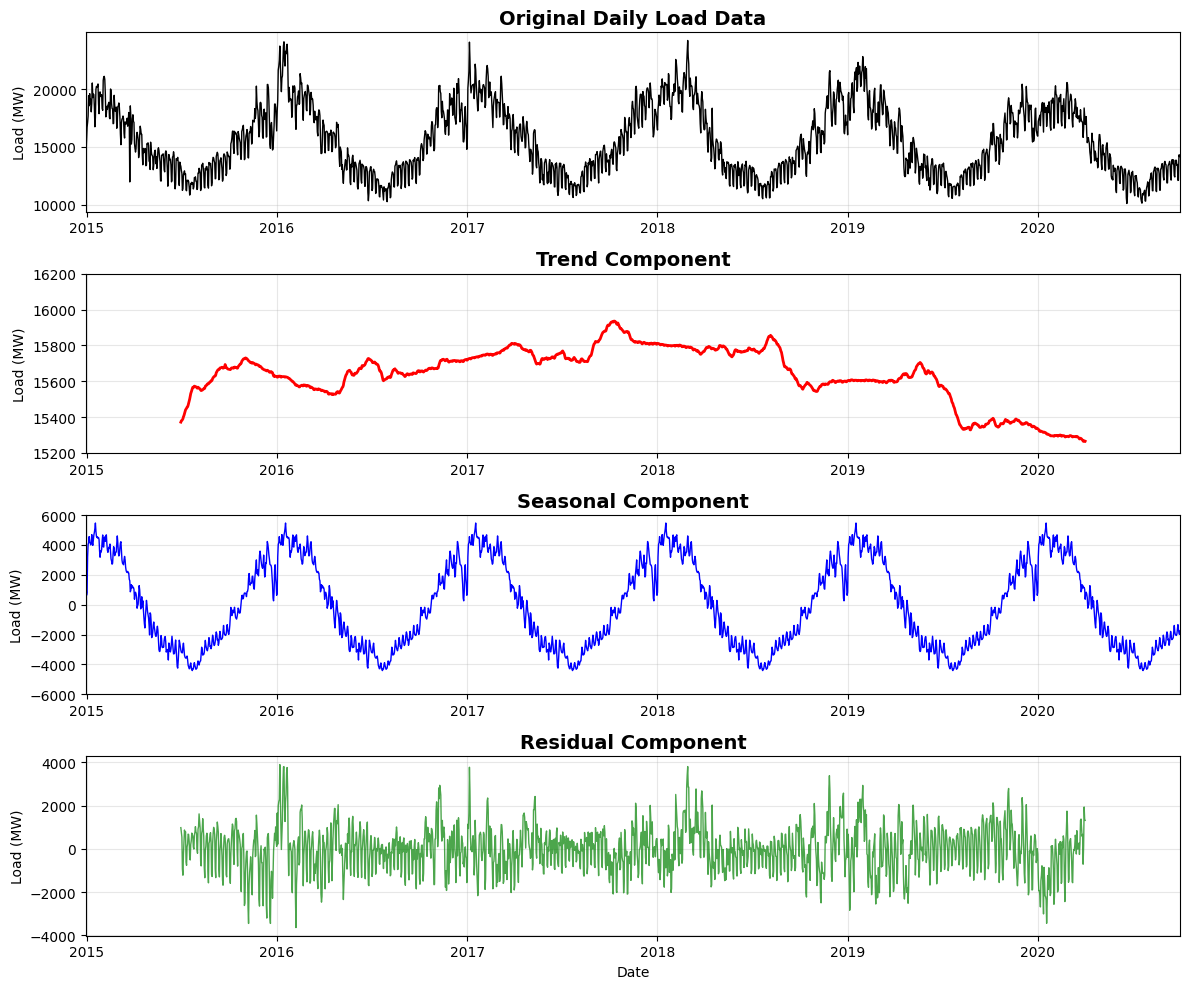

In [65]:
# Time series decomposition using statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to daily data for cleaner decomposition (hourly is too noisy)
daily_data = df.resample('D')['SE_load_actual_entsoe_transparency'].mean()

print(f"📊 Daily resampling: {len(daily_data)} daily observations")
print(f"📅 Date range: {daily_data.index.min().strftime('%Y-%m-%d')} to {daily_data.index.max().strftime('%Y-%m-%d')}")

# Perform seasonal decomposition
# Using additive model: observed = trend + seasonal + residual
decomposition = seasonal_decompose(daily_data, model='additive', period=365)  # Annual seasonality

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Original data
axes[0].plot(daily_data.index, daily_data.values, color='black', linewidth=1)
axes[0].set_title('Original Daily Load Data', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].grid(True, alpha=0.3)

# Trend component
axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='red', linewidth=2)
axes[1].set_title('Trend Component', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Load (MW)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(15200, 16200)

# Seasonal component
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='blue', linewidth=1)
axes[2].set_title('Seasonal Component', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Load (MW)')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-6000, 6000)


# Residual component
axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='green', linewidth=1, alpha=0.7)
axes[3].set_title('Residual Component', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Load (MW)')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

# Set consistent x-axis limits for all subplots
x_min, x_max = daily_data.index.min(), daily_data.index.max()

for ax in axes:
    ax.set_xlim(x_min, x_max)  # Ensure all plots cover the same time range

# Print decomposition insights
trend_start = decomposition.trend.dropna().iloc[0]
trend_end = decomposition.trend.dropna().iloc[-1]
trend_change = trend_end - trend_start
seasonal_range = decomposition.seasonal.max() - decomposition.seasonal.min()
residual_std = decomposition.resid.std()

print(f"\n📈 Overall Decomposition Analysis:")

print(f"   Trend change: {trend_change:+.1f} MW over the period")
print(f"   Trend change rate: {((trend_end - trend_start) / ((daily_data.index[-1] - daily_data.index[0]).days / 365.25)):+.1f} MW/year")
print(f"   Max. seasonal variation range: {seasonal_range:.1f} MW (peak-to-valley)")
print(f"   Max. seasonal variation: ±{(seasonal_range / 2 / daily_data.mean() * 100):.1f}% around average load")
print(f"   Residual standard deviation: {residual_std:.1f} MW")

plt.tight_layout()
plt.show()


🌡️ Annual Seasonality Analysis:
   Average seasonal deviation range: 7907 MW (peak-to-valley)
   Winter months (Dec-Feb) avg seasonal deviation: +3433 MW
   Spring months (Mar-May) avg seasonal deviation: +135 MW
   Summer months (Jun-Aug) avg seasonal deviation: -3284 MW
   Autumn months (Sep-Nov) avg seasonal deviation: -216 MW
   Winter vs Summer seasonal avg difference: 6717 MW


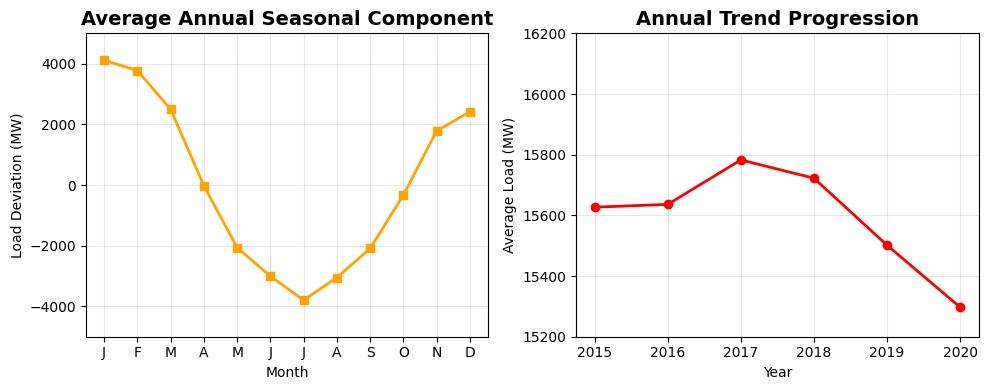

In [85]:
# Seasonal pattern analysis - decomposition insights
from scipy import stats
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Annual seasonal pattern (monthly averages)
monthly_seasonal_trend = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()
axes[0].plot(range(1, 13), monthly_seasonal_trend.values, marker='s', linewidth=2, color='orange')
axes[0].set_title('Average Annual Seasonal Component', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Load Deviation (MW)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-5000, 5000)

# Trend analysis - yearly progression
yearly_trend = decomposition.trend.groupby(decomposition.trend.index.year).mean()
axes[1].plot(yearly_trend.index, yearly_trend.values, marker='o', linewidth=2, color='red')
axes[1].set_title('Annual Trend Progression', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Load (MW)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(15200, 16200)

# Annual pattern insights
average_seasonal_deviation_range = monthly_seasonal_trend.max() - monthly_seasonal_trend.min()
annual_winter = monthly_seasonal_trend[[12, 1, 2]].mean()  # Dec, Jan, Feb
annual_summer = monthly_seasonal_trend[[6, 7, 8]].mean()   # Jun, Jul, Aug
annual_spring = monthly_seasonal_trend[[3, 4, 5]].mean()   # Mar, Apr, May
annual_autumn = monthly_seasonal_trend[[9, 10, 11]].mean() # Sep, Oct, Nov

print(f"🌡️ Annual Seasonality Analysis:")
print(f"   Average seasonal deviation range: {average_seasonal_deviation_range:.0f} MW (peak-to-valley)")
print(f"   Winter months (Dec-Feb) avg seasonal deviation: {annual_winter:+.0f} MW")
print(f"   Spring months (Mar-May) avg seasonal deviation: {annual_spring:+.0f} MW")
print(f"   Summer months (Jun-Aug) avg seasonal deviation: {annual_summer:+.0f} MW")
print(f"   Autumn months (Sep-Nov) avg seasonal deviation: {annual_autumn:+.0f} MW")
print(f"   Winter vs Summer seasonal avg difference: {annual_winter - annual_summer:.0f} MW")

plt.tight_layout()
plt.show()

📊 Residual Distribution Analysis:
   Residual mean: -8.6 MW (should be ~0)
   Residual std: 1072.4 MW
   Residual skewness: 0.078 (normal=0)
   Residual kurtosis: 0.587 (normal=0)
   Shapiro-Wilk test: statistic=0.9934, p-value=0.000001
   ❌ Residuals deviate from normal distribution
   📝 Normal fit parameters: μ=-8.6 MW, σ=1072.4 MW

🔍 Autocorrelation Analysis:
   Weekly autocorrelations (significant if |r| > 0.047):
   Lag  7 days: r=+0.580 (⚠️  Significant)
   Lag 14 days: r=+0.398 (⚠️  Significant)
   Lag 21 days: r=+0.404 (⚠️  Significant)
   🔶 Weekly correlations detected in residuals!
   📝 This suggests the annual decomposition (period=365) did not fully capture weekly patterns
   💡 Consider: Multi-seasonal decomposition or additional weekly components for better modeling

🎯 Normality Implications:
   📈 Current residual distribution may be affected by remaining weekly patterns
   🔄 Accounting for weekly correlations could improve residual normality
   📊 Methods to try:
      • M

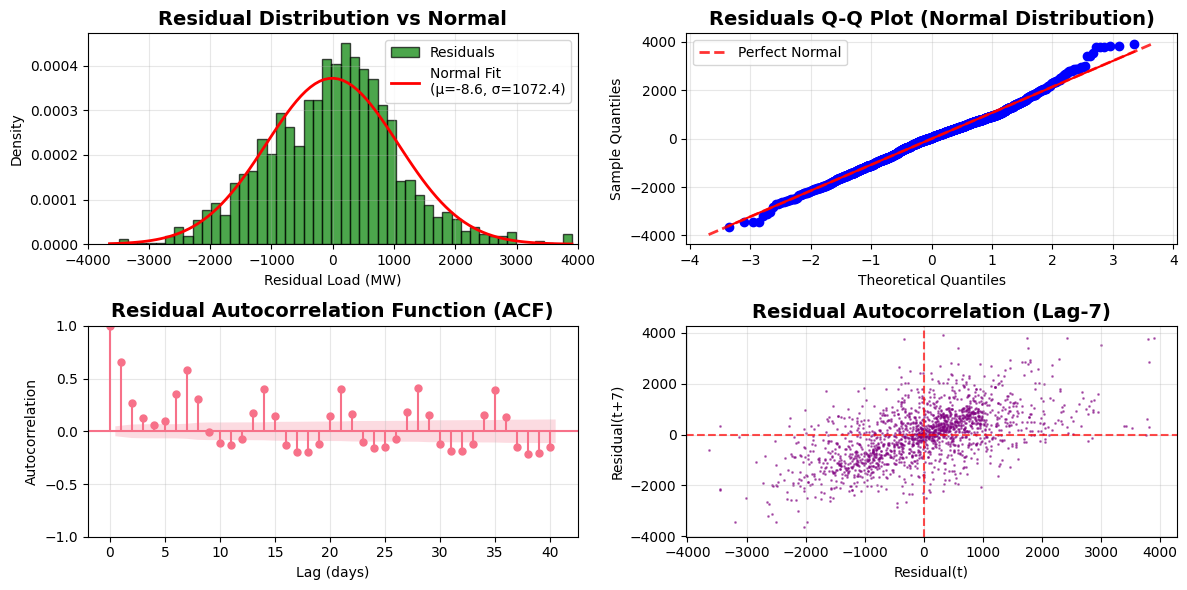

In [88]:
# Residual analysis - distribution and autocorrelation diagnostics
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Get residuals for analysis
residuals = decomposition.resid.dropna()

# Residual distribution and normality check
axes[0, 0].hist(residuals, bins=50, alpha=0.7, color='green', edgecolor='black', density=True, label='Residuals')

# Fit normal distribution
mu, sigma = stats.norm.fit(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
normal_fit = stats.norm.pdf(x, mu, sigma)
axes[0, 0].plot(x, normal_fit, 'r-', linewidth=2, label=f'Normal Fit\n(μ={mu:.1f}, σ={sigma:.1f})')

axes[0, 0].set_title('Residual Distribution vs Normal', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Residual Load (MW)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(-4000, 4000)

# Q-Q plot for normality assessment
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Residuals Q-Q Plot (Normal Distribution)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Theoretical Quantiles')
axes[0, 1].set_ylabel('Sample Quantiles')
axes[0, 1].grid(True, alpha=0.3)
line_x = np.array(axes[0, 1].get_xlim()) # Add reference line for perfect normal distribution
line_y = mu + sigma * line_x
axes[0, 1].plot(line_x, line_y, 'r--', alpha=0.8, linewidth=2, label='Perfect Normal')
axes[0, 1].legend()

# Calculate and plot autocorrelation function
plot_acf(residuals, ax=axes[1, 0], lags=40, alpha=0.05)
axes[1, 0].set_title('Residual Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Lag (days)')
axes[1, 0].set_ylabel('Autocorrelation')
axes[1, 0].grid(True, alpha=0.3)

# Residual autocorrelation (simple lag-7 scatter)
residuals_series = pd.Series(residuals.values)
axes[1, 1].scatter(residuals_series[:-7], residuals_series[7:], alpha=0.5, s=1, color='purple')
axes[1, 1].set_title('Residual Autocorrelation (Lag-7)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Residual(t)')
axes[1, 1].set_ylabel('Residual(t+7)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7)

# Residual normality tests
print(f"📊 Residual Distribution Analysis:")
print(f"   Residual mean: {mu:.1f} MW (should be ~0)")
print(f"   Residual std: {sigma:.1f} MW")
print(f"   Residual skewness: {stats.skew(residuals):.3f} (normal=0)")
print(f"   Residual kurtosis: {stats.kurtosis(residuals):.3f} (normal=0)")

# Shapiro-Wilk test for normality (works well for smaller samples)
if len(residuals) <= 5000:  # Shapiro-Wilk works best for n<=5000
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"   Shapiro-Wilk test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")
    print(f"   {'✅ Residuals appear normally distributed' if shapiro_p > 0.05 else '❌ Residuals deviate from normal distribution'}")
else:
    # Use Anderson-Darling test for larger samples
    anderson_stat, anderson_critical, anderson_sig = stats.anderson(residuals, dist='norm')
    print(f"   Anderson-Darling test: statistic={anderson_stat:.4f}")
    print(f"   {'✅ Residuals appear normally distributed' if anderson_stat < anderson_critical[2] else '❌ Residuals deviate from normal distribution'}")

print(f"   📝 Normal fit parameters: μ={mu:.1f} MW, σ={sigma:.1f} MW")

# ACF analysis for remaining patterns
print(f"\n🔍 Autocorrelation Analysis:")
# Calculate ACF values for specific weekly lags
acf_values = acf(residuals, nlags=21, fft=True)
weekly_lags = [7, 14, 21]
significant_threshold = 1.96 / np.sqrt(len(residuals))  # 95% confidence threshold

print(f"   Weekly autocorrelations (significant if |r| > {significant_threshold:.3f}):")
for lag in weekly_lags:
    acf_val = acf_values[lag]
    is_significant = abs(acf_val) > significant_threshold
    status = "⚠️  Significant" if is_significant else "✅ Not significant"
    print(f"   Lag {lag:2d} days: r={acf_val:+.3f} ({status})")

# Check for overall weekly pattern
weekly_pattern_detected = any(abs(acf_values[lag]) > significant_threshold for lag in weekly_lags)
if weekly_pattern_detected:
    print(f"   🔶 Weekly correlations detected in residuals!")
    print(f"   📝 This suggests the annual decomposition (period=365) did not fully capture weekly patterns")
    print(f"   💡 Consider: Multi-seasonal decomposition or additional weekly components for better modeling")
    
    # Additional insight about normality
    print(f"\n🎯 Normality Implications:")
    print(f"   📈 Current residual distribution may be affected by remaining weekly patterns")
    print(f"   🔄 Accounting for weekly correlations could improve residual normality")
    print(f"   📊 Methods to try:")
    print(f"      • Multi-seasonal decomposition (annual + weekly)")
    print(f"      • STL decomposition with multiple seasonal periods")
    print(f"      • SARIMA modeling with weekly seasonal component")
    print(f"   ✨ Expected outcome: More normally distributed residuals after removing weekly patterns")
else:
    print(f"   ✅ No significant weekly correlations - decomposition successfully captured weekly patterns")

plt.tight_layout()
plt.show()

---

## 🔄 Task 4: Seasonal and Weekly Pattern Analysis

Investigate how weekly patterns change throughout the year - do weekday/weekend differences vary by season?

The Analysis:

1. Seasonal Breakdown: Compares weekly patterns across Winter, Spring, Summer, and Autumn
2. Individual Season Plots: Shows demand patterns for each day of the week by season
3. Seasonal Comparison: Overlays all seasons to see differences
4. Weekday vs Weekend Analysis: Quantifies business cycle effects by season

Expected Insights:

* Winter: Might show flatter weekly patterns (heating needed 7 days/week)
* Summer: Could have stronger weekday/weekend differences (A/C mainly during business hours)
* Holiday Effects: December might show unusual patterns due to holidays

🌡️ Monthly Heatmap Analysis

Deep Dive Features:

1. Absolute Heatmap: Shows actual MW demand by month and weekday
2. Relative Heatmap: Shows % deviation from each month's mean (removes seasonal effects)
3. Business Cycle Tracking: Measures weekday/weekend differences month by month
4. Holiday Pattern Detection: Identifies months with unusual weekly patterns

What to Look For:

* July/August: Might show different patterns due to summer holidays
* December: Could show disrupted business cycles due to Christmas/New Year
* Color Patterns: Red/blue patterns reveal when weekends are most/least different from weekdays

Forecasting Implications:

* If weekly patterns vary by season, your forecasting model needs seasonal weekly adjustments
* Holiday months might need special treatment in forecasting
* Understanding these patterns helps explain forecast errors during specific periods

This analysis will show whether Sweden's weekly electricity patterns are stable year-round or if they vary significantly with seasons, holidays, and cultural patterns!

🔄 How do weekly patterns change by season?


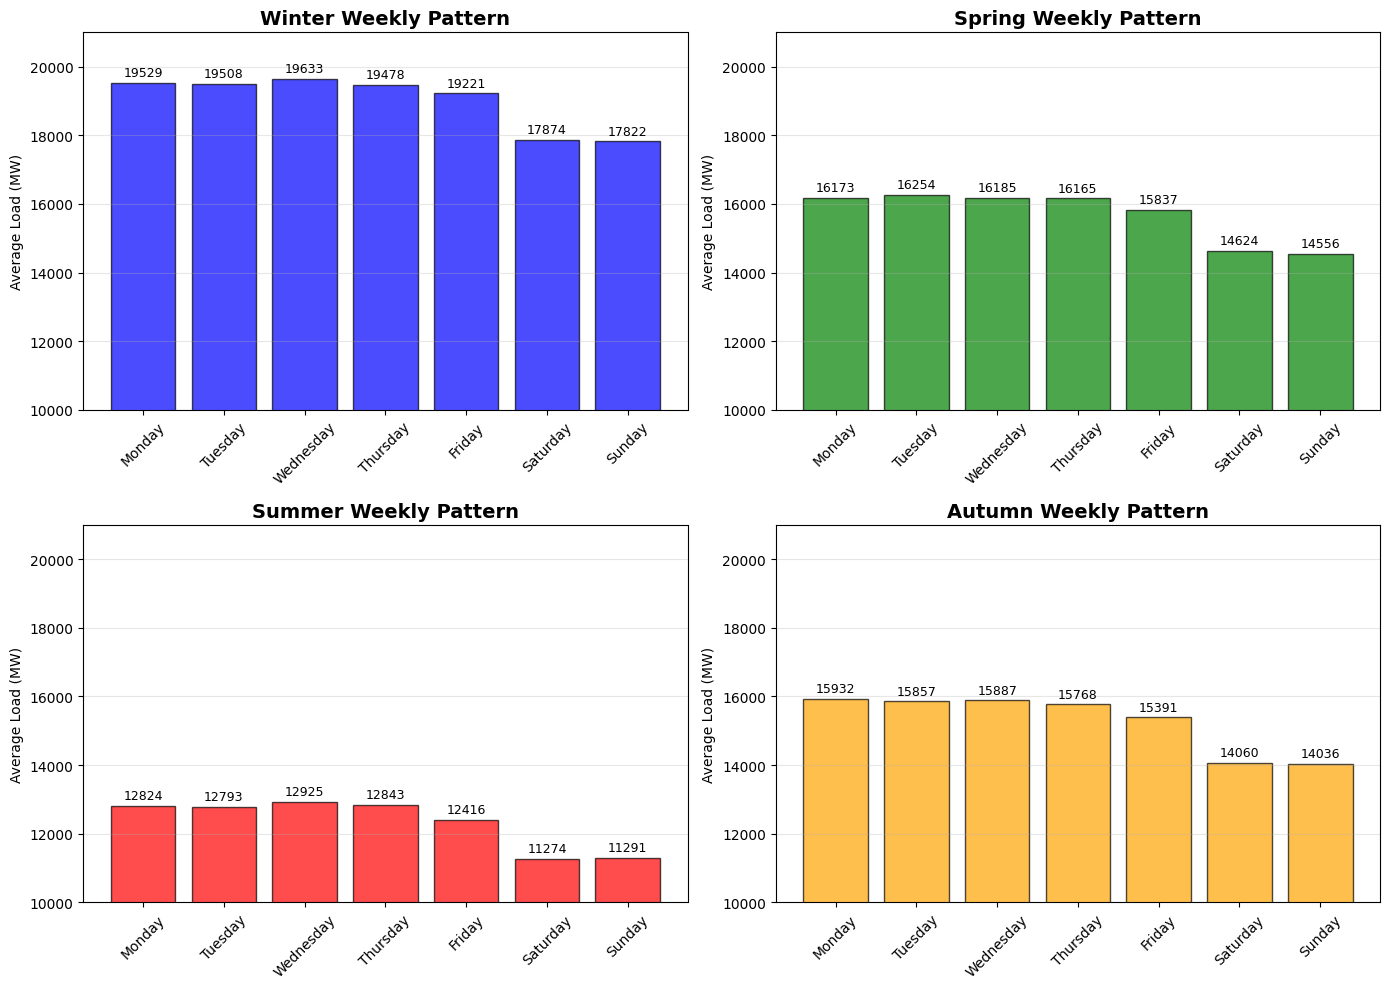


📊 Weekday vs Weekend Analysis by Season:
--------------------------------------------------
Winter:
   Weekday average: 19474 MW
   Weekend average: 17848 MW
   Difference: +1626 MW (+9.1%)

Spring:
   Weekday average: 16123 MW
   Weekend average: 14590 MW
   Difference: +1533 MW (+10.5%)

Summer:
   Weekday average: 12760 MW
   Weekend average: 11283 MW
   Difference: +1477 MW (+13.1%)

Autumn:
   Weekday average: 15767 MW
   Weekend average: 14048 MW
   Difference: +1719 MW (+12.2%)



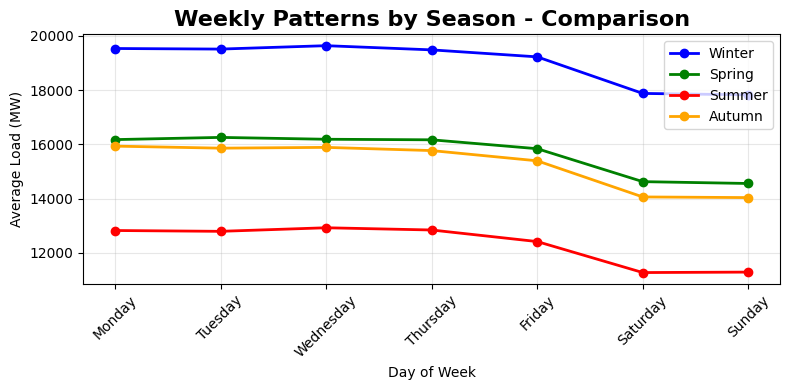


💡 Key Insights:
   • Autumn has the largest weekly variation (1896 MW)
   • Summer has the smallest weekly variation (1650 MW)
   • Difference between max and min seasonal ranges: 246 MW


In [33]:
# Seasonal Weekly Pattern Analysis
print("🔄 How do weekly patterns change by season?")
print("=" * 60)

# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Add season column
df['season'] = df['month'].apply(get_season)

# Calculate weekly patterns by season
seasonal_weekly_patterns = {}
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for season in seasons:
    season_data = df[df['season'] == season]
    seasonal_weekly_patterns[season] = season_data.groupby('weekday')['SE_load_actual_entsoe_transparency'].mean()

# Plot seasonal weekly patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

colors = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Autumn': 'orange'}

# Calculate consistent y-axis range across all seasons
all_values = []
for season in seasons:
    all_values.extend(seasonal_weekly_patterns[season].values)
y_min = 10000  # Set a reasonable minimum    
y_max = 21000  # Set a reasonable maximum
# y_min = min(all_values) * 0.95  # Add 5% padding
# y_max = max(all_values) * 1.05

for i, season in enumerate(seasons):
    ax = axes_flat[i]
    pattern = seasonal_weekly_patterns[season]
    
    ax.bar(weekday_names, pattern.values, color=colors[season], alpha=0.7, edgecolor='black')
    ax.set_title(f'{season} Weekly Pattern', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Load (MW)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set consistent y-axis limits
    ax.set_ylim(y_min, y_max)
    
    # Add value labels on bars
    for j, v in enumerate(pattern.values):
        ax.text(j, v + (y_max - y_min) * 0.01, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate weekday vs weekend differences by season
print(f"\n📊 Weekday vs Weekend Analysis by Season:")
print("-" * 50)

for season in seasons:
    pattern = seasonal_weekly_patterns[season]
    weekday_avg = pattern[:5].mean()  # Mon-Fri
    weekend_avg = pattern[5:].mean()   # Sat-Sun
    difference = weekday_avg - weekend_avg
    pct_difference = (difference / weekend_avg) * 100
    
    print(f"{season}:")
    print(f"   Weekday average: {weekday_avg:.0f} MW")
    print(f"   Weekend average: {weekend_avg:.0f} MW")
    print(f"   Difference: {difference:+.0f} MW ({pct_difference:+.1f}%)")
    print()

# Show all patterns together for comparison
fig, ax = plt.subplots(figsize=(8, 4))

for season in seasons:
    pattern = seasonal_weekly_patterns[season]
    ax.plot(weekday_names, pattern.values, marker='o', linewidth=2, 
            label=season, color=colors[season])

ax.set_title('Weekly Patterns by Season - Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Load (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
seasonal_ranges = {}
for season in seasons:
    pattern = seasonal_weekly_patterns[season]
    seasonal_ranges[season] = pattern.max() - pattern.min()

max_range_season = max(seasonal_ranges, key=seasonal_ranges.get)
min_range_season = min(seasonal_ranges, key=seasonal_ranges.get)

print(f"   • {max_range_season} has the largest weekly variation ({seasonal_ranges[max_range_season]:.0f} MW)")
print(f"   • {min_range_season} has the smallest weekly variation ({seasonal_ranges[min_range_season]:.0f} MW)")
print(f"   • Difference between max and min seasonal ranges: {max(seasonal_ranges.values()) - min(seasonal_ranges.values()):.0f} MW")

🌡️ Monthly Weekly Pattern Heatmap - Deep Dive


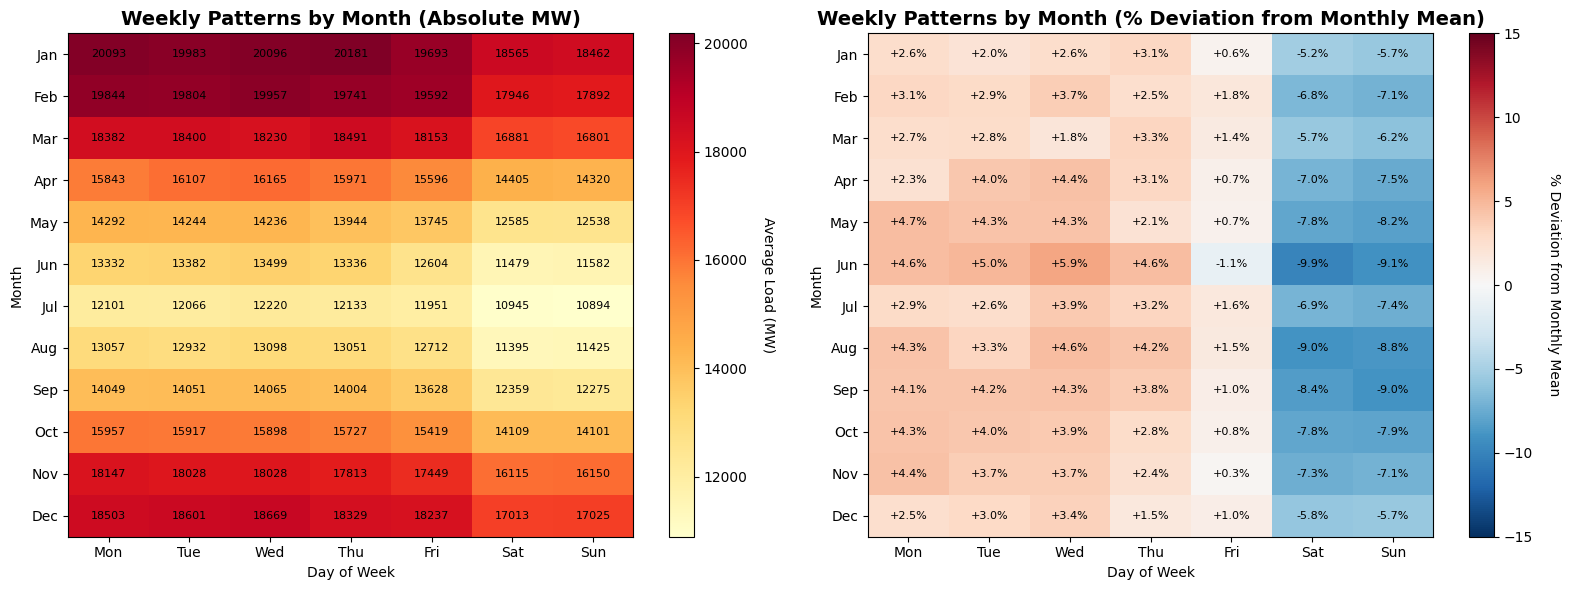


📈 Weekend vs Weekday Analysis by Month:
---------------------------------------------
Jan: +8.08% (weekdays vs weekends)
Feb: +10.43% (weekdays vs weekends)
Mar: +8.85% (weekdays vs weekends)
Apr: +10.96% (weekdays vs weekends)
May: +12.18% (weekdays vs weekends)
Jun: +14.74% (weekdays vs weekends)
Jul: +10.76% (weekdays vs weekends)
Aug: +13.67% (weekdays vs weekends)
Sep: +13.34% (weekdays vs weekends)
Oct: +11.90% (weekdays vs weekends)
Nov: +10.91% (weekdays vs weekends)
Dec: +8.51% (weekdays vs weekends)

🎯 Business Cycle Insights:
   • Strongest business cycle: Jun (+14.74%)
   • Weakest business cycle: Jan (+8.08%)
   • This suggests holiday periods or seasonal work patterns affect electricity demand!


In [17]:
# Monthly Weekly Pattern Heatmap
print("🌡️ Monthly Weekly Pattern Heatmap - Deep Dive")
print("=" * 60)

# Calculate weekly patterns for each month
monthly_weekly_patterns = {}
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create matrix for heatmap
heatmap_data = np.zeros((12, 7))  # 12 months x 7 days

for month in range(1, 13):
    month_data = df[df['month'] == month]
    weekly_pattern = month_data.groupby('weekday')['SE_load_actual_entsoe_transparency'].mean()
    monthly_weekly_patterns[month] = weekly_pattern
    heatmap_data[month-1, :] = weekly_pattern.values

# Create heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolute values heatmap
im1 = ax1.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax1.set_title('Weekly Patterns by Month (Absolute MW)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Month')
ax1.set_xticks(range(7))
ax1.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax1.set_yticks(range(12))
ax1.set_yticklabels(month_names)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Average Load (MW)', rotation=270, labelpad=20)

# Add text annotations
for i in range(12):
    for j in range(7):
        text = ax1.text(j, i, f'{heatmap_data[i, j]:.0f}', 
                       ha="center", va="center", color="black", fontsize=8)

# Relative differences heatmap (compared to each month's mean)
relative_data = np.zeros((12, 7))
for i in range(12):
    month_mean = heatmap_data[i, :].mean()
    relative_data[i, :] = ((heatmap_data[i, :] - month_mean) / month_mean) * 100

im2 = ax2.imshow(relative_data, cmap='RdBu_r', aspect='auto', vmin=-15, vmax=15)
ax2.set_title('Weekly Patterns by Month (% Deviation from Monthly Mean)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Month')
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax2.set_yticks(range(12))
ax2.set_yticklabels(month_names)

# Add colorbar
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('% Deviation from Monthly Mean', rotation=270, labelpad=20)

# Add text annotations
for i in range(12):
    for j in range(7):
        text = ax2.text(j, i, f'{relative_data[i, j]:+.1f}%', 
                       ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

# Analysis of weekend/weekday ratios by month
print(f"\n📈 Weekend vs Weekday Analysis by Month:")
print("-" * 45)

weekend_weekday_ratios = {}
for month in range(1, 13):
    pattern = monthly_weekly_patterns[month]
    weekday_avg = pattern[:5].mean()
    weekend_avg = pattern[5:].mean()
    ratio = (weekday_avg - weekend_avg) / weekend_avg * 100
    weekend_weekday_ratios[month] = ratio
    
    print(f"{month_names[month-1]}: {ratio:+.2f}% (weekdays vs weekends)")

# Find months with most/least business cycle effect
max_ratio_month = max(weekend_weekday_ratios, key=weekend_weekday_ratios.get)
min_ratio_month = min(weekend_weekday_ratios, key=weekend_weekday_ratios.get)

print(f"\n🎯 Business Cycle Insights:")
print(f"   • Strongest business cycle: {month_names[max_ratio_month-1]} ({weekend_weekday_ratios[max_ratio_month]:+.2f}%)")
print(f"   • Weakest business cycle: {month_names[min_ratio_month-1]} ({weekend_weekday_ratios[min_ratio_month]:+.2f}%)")
print(f"   • This suggests holiday periods or seasonal work patterns affect electricity demand!")